In [ ]:
import os
print(os.getcwd())


In [ ]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append('..')

import utilities.functions as functions

from utilities.functions import (
    load_data,
    check_key_uniqueness,
    merge_df,
    load_orders,
    process_orders_pandas
)

In [ ]:
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 
df_pub_u = pd.read_parquet(BASE_PATH / "silver" / "df_p_2.parquet")

In [ ]:
df_pub_u.head()

In [ ]:
df=df_pub_u

In [ ]:
df.drop([ "delivery_address_district", "delivery_address_country",'customer_name','active','created_at','delivery_address_external_id'], axis=1, inplace=True)

In [30]:
df["order_created_at"] = pd.to_datetime(df["order_created_at"], utc=True)
df["day_month_year"] = df["order_created_at"].dt.strftime("%d-%m-%Y")
df["weekday"] = df["order_created_at"].dt.day_name()
df["hour"] = df["order_created_at"].dt.hour
df["order_created_month"] = df["order_created_at"].dt.month
df=df[df['order_created_month']==12]

In [31]:
df_stats_mes = (
    df.groupby(['order_created_month', 'delivery_address_state'])
      .agg(
          total_clientes=('customer_id', 'nunique'),
          total_pedidos=('order_id', 'count'),
          total_ordem=('order_total_amount', 'sum')
      )
      .reset_index()
      .assign(
          perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                     .transform(lambda x: x / x.sum() * 100),
          perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                    .transform(lambda x: x / x.sum() * 100),
          perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                   .transform(lambda x: x / x.sum() * 100)
      )
      .round(2)
).sort_values("perc_amount", ascending=False).reset_index(drop=True)


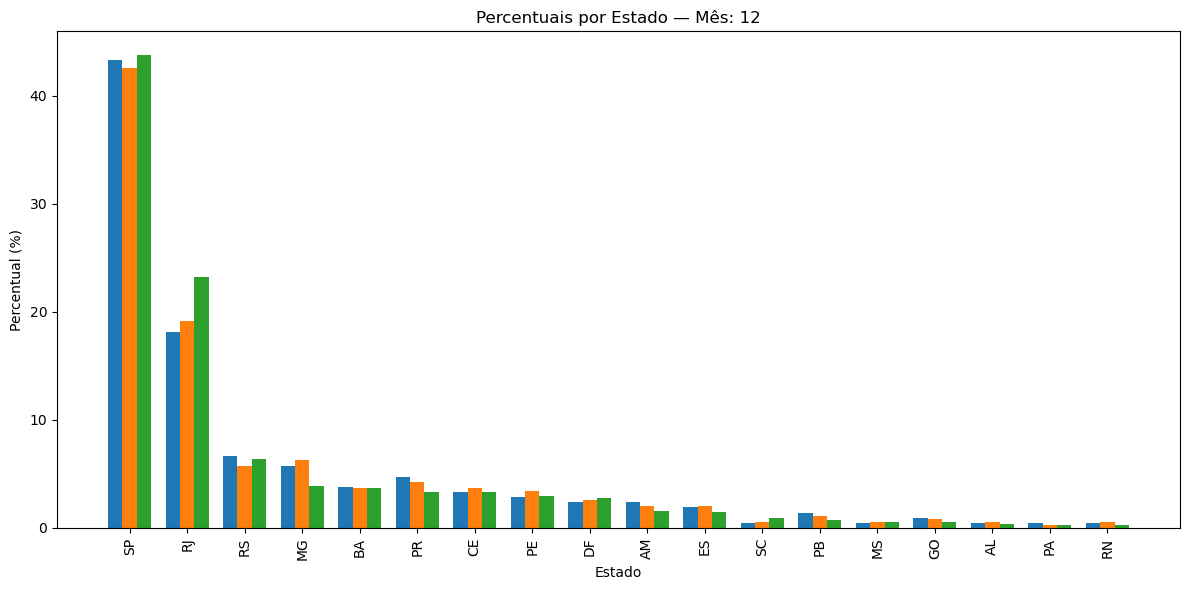

In [32]:
import numpy as np
import matplotlib.pyplot as plt

variaveis = ["perc_clientes", "perc_pedidos", "perc_amount"]

for mes in df_stats_mes["order_created_month"].unique():

    # Filtra o mês atual
    subset = df_stats_mes[df_stats_mes["order_created_month"] == mes]

    # Ordena do maior para o menor (ex: perc_amount)
    subset = subset.sort_values("perc_amount", ascending=False)

    estados = subset["delivery_address_state"].tolist()
    x = np.arange(len(estados))
    width = 0.25  # largura das barras agrupadas

    plt.figure(figsize=(12,6))

    for i, var in enumerate(variaveis):
        valores = subset[var].values
        plt.bar(x + i*width, valores, width)

    plt.xticks(x + width, estados, rotation=90)
    plt.title(f"Percentuais por Estado — Mês: {mes}")
    plt.xlabel("Estado")
    plt.ylabel("Percentual (%)")

    plt.tight_layout()
    plt.show()


In [33]:
import numpy as np

# 1. Copia pra não mexer no original
df_group = df_stats_mes.copy()

# 2. Cria uma coluna de estado agrupado:
#    se perc_amount < 5 → "Outros", senão mantém o estado original
df_group["state_grouped"] = np.where(
    df_group["perc_amount"] < 5,
    "Outros",
    df_group["delivery_address_state"]
)

# 3. Agrupa por mês + estado_agrupado e recalcula totais
df_group = (
    df_group
    .groupby(['order_created_month', 'state_grouped'])
    .agg(
        total_clientes=('total_clientes', 'sum'),
        total_pedidos=('total_pedidos', 'sum'),
        total_ordem=('total_ordem', 'sum')
    )
    .reset_index()
)

# 4. Recalcula os percentuais dentro de cada mês
df_group = (
    df_group
    .assign(
        perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                   .transform(lambda x: x / x.sum() * 100),
        perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                  .transform(lambda x: x / x.sum() * 100),
        perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                 .transform(lambda x: x / x.sum() * 100)
    )
    .round(2).sort_values("perc_amount", ascending=False).reset_index(drop=True)
)

df_group


,order_created_month,state_grouped,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,12,SP,91,149,7104.26,43.33,42.57,43.79
1,12,Outros,67,114,4315.21,31.90,32.57,26.60
2,12,RJ,38,67,3767.10,18.10,19.14,23.22
3,12,RS,14,20,1037.83,6.67,5.71,6.40


In [34]:
df.head()

,customer_id,is_target,delivery_address_city,delivery_address_latitude,delivery_address_longitude,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform,day_month_year,weekday,hour,order_created_month
2,6206f4b585fdd39a5a14bdbac75442a0cb728234d735cd...,target,RIBEIRAO PRETO,-47.83,-21.23,SP,9efa7e40269f04be813a7100582a23ecb3e9266d5d3932...,2018-12-27 15:48:09+00:00,d81ef123beb69b1a50a1c74883454d11c35016a5efa642...,25.0,DESKTOP,27-12-2018,Thursday,15,12
3,6206f4b585fdd39a5a14bdbac75442a0cb728234d735cd...,target,RIBEIRAO PRETO,-47.83,-21.23,SP,9efa7e40269f04be813a7100582a23ecb3e9266d5d3932...,2018-12-03 14:46:18+00:00,3d13dc27ccbbcc5c530dce062fbf849ae3b1e7f11a6a15...,50.6,DESKTOP,03-12-2018,Monday,14,12
6,ff4770f539de10af59e9f33b00fa740820b4b770c28692...,target,LONDRINA,-51.15,-23.32,PR,c344e00b8d15e64f9303815986bcfa95188908d32881e3...,2018-12-03 16:05:25+00:00,66838418b2ef145a2898dbac2c326cc1f0f610f3d2b9fd...,19.0,IOS,03-12-2018,Monday,16,12
10,7fa883f6925c6d653186bac68ebbbf6f916f76b0cedf94...,target,SAO PAULO,-46.68,-23.53,SP,d487db01cf96b9f2f24c7b26ef68cbfd54ae2699164d4a...,2018-12-28 17:53:14+00:00,0f2f411fac2fdd8c36cd766e0ceed0007ff2232970b4d8...,36.2,IOS,28-12-2018,Friday,17,12
11,7fa883f6925c6d653186bac68ebbbf6f916f76b0cedf94...,target,SAO PAULO,-46.68,-23.53,SP,935cc7ffd92a1f6d4ca24164ff6dedcea08622ac8c900a...,2018-12-03 14:24:32+00:00,d334f3f96b7029d32994cdfe20192863e8b934e4e85260...,37.5,IOS,03-12-2018,Monday,14,12


In [39]:
df_stats_mes = (
    df.groupby(['order_created_month','weekday','hour'#'origin_platform'
                ]
                )
      .agg(
          total_clientes=('customer_id', 'nunique'),
          total_pedidos=('order_id', 'count'),
          total_ordem=('order_total_amount', 'sum')
      )
      .reset_index()
      .assign(
          perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                     .transform(lambda x: x / x.sum() * 100),
          perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                    .transform(lambda x: x / x.sum() * 100),
          perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                   .transform(lambda x: x / x.sum() * 100)
      )
      .round(2)
).sort_values(['order_created_month',"perc_amount"], ascending=False).reset_index(drop=True)
df_stats_mes.head()
#df['origin_platform'].unique()


,order_created_month,weekday,hour,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,12,Friday,22,13,16,786.50,3.86,4.57,4.85
1,12,Monday,0,13,13,711.31,3.86,3.71,4.38
2,12,Friday,23,11,12,644.55,3.26,3.43,3.97
3,12,Sunday,22,13,13,591.75,3.86,3.71,3.65
4,12,Saturday,23,13,14,581.53,3.86,4.00,3.58


In [42]:
df=df_stats_mes
df

,order_created_month,weekday,hour,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,12,Friday,22,13,16,786.50,3.86,4.57,4.85
1,12,Monday,0,13,13,711.31,3.86,3.71,4.38
2,12,Friday,23,11,12,644.55,3.26,3.43,3.97
3,12,Sunday,22,13,13,591.75,3.86,3.71,3.65
4,12,Saturday,23,13,14,581.53,3.86,4.00,3.58
...,...,...,...,...,...,...,...,...,...
84,12,Wednesday,20,1,1,21.00,0.30,0.29,0.13
85,12,Tuesday,15,1,1,18.90,0.30,0.29,0.12
86,12,Tuesday,19,1,1,19.50,0.30,0.29,0.12
87,12,Friday,16,1,1,14.50,0.30,0.29,0.09


In [45]:
import streamlit as st

df.to_parquet(BASE_PATH / "gold" / "df_app.parquet", index=False)
estado = st.selectbox("Escolha o estado", df["weekday"].unique())
#mes = st.selectbox("Escolha o mês", df["month"].unique())

df_filtrado = df[(df["weekday"] == estado) #& (df["month"] == mes)
                 ]
st.dataframe(df_filtrado)


DeltaGenerator()

In [ ]:
df_pub_u=process_orders_pandas(df_pub_u)

In [ ]:
df_pub_un = df_pub_u[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()

In [ ]:
#df_pub_u=df_pub_u[df_pub_u['customer_id']=='6206f4b585fdd39a5a14bdbac75442a0cb728234d735cd30fb46cb40a8f5c26b']

In [ ]:
df_pub_un = df[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()